# QCut vs qiskit-addon-cutting

Load env with `uv sync --group benchmark`.

In [1]:
import math
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import RXXGate, RZZGate, efficient_su2
from qiskit.quantum_info import PauliList, SparsePauliOp
from qiskit_addon_cutting import (
    DeviceConstraints,
    OptimizationParameters,
    cut_wires,
    expand_observables,
    find_cuts,
    generate_cutting_experiments,
    partition_problem,
)
from qiskit_addon_cutting.instructions import CutWire

import QCut as ck
from QCut import CutOptions, cut, cutGate
from QCut.qpd.qpd_operations import plan_cost

## Circuit families

Each returns the circuit marked for QCut, the circuit for the addon, and how the addon should split it. The cuts land in the same places for both.
`mixed_axes` is here because on single axis QCut will win on the joint decomposition for parallel rotations but for mixed axes this is not possible.
On `mixed_axes` QCut wins due to `consolidate` merging consecutive cut gates.

In [2]:
def single_z(width):
    return SparsePauliOp(["I" * (width - 1 - i) + "Z" + "I" * i for i in range(width)])


def parallel_rotations(pairs):
    """`pairs` rotation gates crossing one split, all schedulable at once."""
    width = 2 * pairs
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for q in range(width):
            c.ry(0.3 + 0.1 * q, q)
        # holds each half together, or the circuit falls into single-qubit pieces
        for q in range(pairs - 1):
            c.rzz(0.4, q, q + 1)
            c.rzz(0.4, pairs + q, pairs + q + 1)
    for i in range(pairs):
        marked.append(**cutGate(RZZGate(0.5 + 0.15 * i), i, pairs + i))
        plain.rzz(0.5 + 0.15 * i, i, pairs + i)
    return marked, plain, "A" * pairs + "B" * pairs, False


def parallel_wires(wires):
    """`wires` wires cut at the same point."""
    width = wires + 2
    marked, addon = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, addon):
        c.h(0)
        for q in range(1, wires + 1):
            c.cx(0, q)
    for q in range(1, wires + 1):
        marked.append(cut(), [q])
        addon.append(CutWire(), [q])
    for c in (marked, addon):
        for q in range(1, wires + 1):
            c.cx(q, width - 1)
    return marked, addon, None, True


def qaoa_layer(nodes, degree=2, seed=7):
    """One QAOA layer on a random regular graph, split down the middle."""
    graph = nx.random_regular_graph(degree, nodes, seed=seed)
    half = nodes // 2
    marked, plain = QuantumCircuit(nodes), QuantumCircuit(nodes)
    for c in (marked, plain):
        for q in range(nodes):
            c.h(q)
    for a, b in graph.edges():
        plain.rzz(0.8, a, b)
        if (a < half) != (b < half):
            marked.append(**cutGate(RZZGate(0.8), a, b))
        else:
            marked.rzz(0.8, a, b)
    for c in (marked, plain):
        for q in range(nodes):
            c.rx(0.6, q)
    return marked, plain, "A" * half + "B" * (nodes - half), False


def mixed_axes(pairs):
    """rzz then rxx on each crossing pair: the product is a generic unitary, so it
    cannot be bundled and consolidation matters."""
    width = 2 * pairs
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for q in range(width):
            c.ry(0.3 + 0.1 * q, q)
        for q in range(pairs - 1):
            c.rzz(0.4, q, q + 1)
            c.rzz(0.4, pairs + q, pairs + q + 1)
    for i in range(pairs):
        marked.append(**cutGate(RZZGate(0.7), i, pairs + i))
        marked.append(**cutGate(RXXGate(0.9), i, pairs + i))
        plain.rzz(0.7, i, pairs + i)
        plain.rxx(0.9, i, pairs + i)
    return marked, plain, "A" * pairs + "B" * pairs, False


FAMILIES = {
    "parallel rotations": (parallel_rotations, [1, 2, 3]),
    "parallel wires": (parallel_wires, [1, 2, 3]),
    "QAOA layer": (qaoa_layer, [4, 5, 6]),
    "mixed axes": (mixed_axes, [1, 2, 3]),
}

## Same cuts, both libraries

In [3]:
def budget_from(labels):
    """The addon is told how to partition, so QCut has to be given the same budget.

    Left free, QCut splits into the circuit's natural connected components, which can be
    more pieces than the labels ask for. Same gamma, but more circuits per group, so the
    counts would not be comparable.
    """
    if labels is None:
        return None
    return [labels.count(label) for label in dict.fromkeys(labels)]


def run_qcut(marked, observables, options=None, max_qubits=None):
    t = perf_counter()
    circuit = ck.get_locations_and_subcircuits(
        marked.copy(), max_qubits=max_qubits, options=options
    )
    experiment = ck.get_experiment_circuits(circuit, observables)
    seconds = perf_counter() - t
    return (
        float(experiment.gamma),
        int(experiment.num_circuits),
        seconds,
        len(circuit.subcircuits),
    )


def run_addon(circuit, observables, labels, wire_cuts):
    paulis = PauliList([p.to_label() for p in observables.paulis])
    t = perf_counter()
    if wire_cuts:
        expanded = cut_wires(circuit)
        problem = partition_problem(
            circuit=expanded,
            observables=expand_observables(paulis, circuit, expanded),
        )
    else:
        problem = partition_problem(
            circuit=circuit, partition_labels=labels, observables=paulis
        )
    subexperiments, coefficients = generate_cutting_experiments(
        circuits=problem.subcircuits,
        observables=problem.subobservables,
        num_samples=np.inf,
    )
    # the coefficient 1-norm, not prod(basis.overhead), which would be gamma squared
    gamma = float(sum(abs(w) for w, _ in coefficients))
    count = int(sum(len(g) for g in subexperiments.values()))
    return gamma, count, perf_counter() - t, len(problem.subcircuits)


exact = CutOptions(expansion="exact")

rows = []
for family, (build, sizes) in FAMILIES.items():
    for size in sizes:
        marked, addon, labels, wire_cuts = build(size)
        observables = single_z(marked.num_qubits)
        budget = budget_from(labels)
        for library, (gamma, count, seconds, pieces) in (
            ("QCut", run_qcut(marked, observables, exact, budget)),
            ("addon", run_addon(addon, observables, labels, wire_cuts)),
        ):
            rows.append(
                {
                    "family": family,
                    "size": size,
                    "library": library,
                    "gamma": gamma,
                    "circuits": count,
                    "pieces": pieces,
                    "seconds": seconds,
                }
            )

same = pd.DataFrame(rows)
same["shots"] = same["gamma"] ** 2
same

,family,size,library,gamma,circuits,pieces,seconds,shots
0,parallel rotations,1,QCut,1.958851,12,2,0.031016,3.837098
1,parallel rotations,1,addon,1.958851,12,2,0.004442,3.837098
2,parallel rotations,2,QCut,3.749508,60,2,0.030009,14.058807
3,parallel rotations,2,addon,4.329791,72,2,0.014316,18.747092
4,parallel rotations,3,QCut,7.156596,264,2,0.205525,51.216862
5,parallel rotations,3,addon,10.541795,432,2,0.090376,111.129448
6,parallel wires,1,QCut,4.000000,16,2,0.003844,16.000000
7,parallel wires,1,addon,4.000000,16,2,0.004259,16.000000
8,parallel wires,2,QCut,7.000000,56,2,0.012868,49.000000
9,parallel wires,2,addon,16.000000,128,2,0.023991,256.000000


In [4]:
wide = same.pivot_table(
    index=["family", "size"],
    columns="library",
    values=["gamma", "circuits", "pieces", "seconds"],
)
ratio = pd.DataFrame(
    {
        "gamma QCut/addon": wide["gamma"]["QCut"] / wide["gamma"]["addon"],
        "shots QCut/addon": (wide["gamma"]["QCut"] / wide["gamma"]["addon"]) ** 2,
        "circuits QCut/addon": wide["circuits"]["QCut"] / wide["circuits"]["addon"],
        # if this is not 1 the two are not cutting into the same number of pieces, and
        # the circuit ratio above is measuring that rather than the decomposition
        "pieces QCut/addon": wide["pieces"]["QCut"] / wide["pieces"]["addon"],
        "build time QCut/addon": wide["seconds"]["QCut"] / wide["seconds"]["addon"],
    }
)
ratio.round(3)

gamma QCut/addon  shots QCut/addon  \
family             size                                       
QAOA layer         4                1.000             1.000   
                   5                1.000             1.000   
                   6                1.000             1.000   
mixed axes         1                0.828             0.686   
                   2                0.686             0.470   
                   3                0.568             0.323   
parallel rotations 1                1.000             1.000   
                   2                0.866             0.750   
                   3                0.679             0.461   
parallel wires     1                1.000             1.000   
                   2                0.438             0.191   
                   3                0.234             0.055   

                         circuits QCut/addon  pieces QCut/addon  \
family             size                                           
QAOA layer         4                   1.000                1.0   
                   5                   1.000                1.0   
                   6                   1.000                1.0   
mixed axes         1                   0.833                1.0   
                   2                   0.694                1.0   
                   3                   0.579                1.0   
parallel rotations 1                   1.000                1.0   
                   2                   0.833                1.0   
                   3                   0.611                1.0   
parallel wires     1                   1.000                1.0   
                   2                   0.438                1.0   
                   3                   0.234                1.0   

                         build time QCut/addon  
family             size                         
QAOA layer         4                     1.178  
                   5                     0.808  
                   6                     0.916  
mixed axes         1                     1.660  
                   2                     0.736  
                   3                     0.324  
parallel rotations 1                     6.982  
                   2                     2.096  
                   3                     2.274  
parallel wires     1                     0.903  
                   2                     0.536  
                   3                     0.176

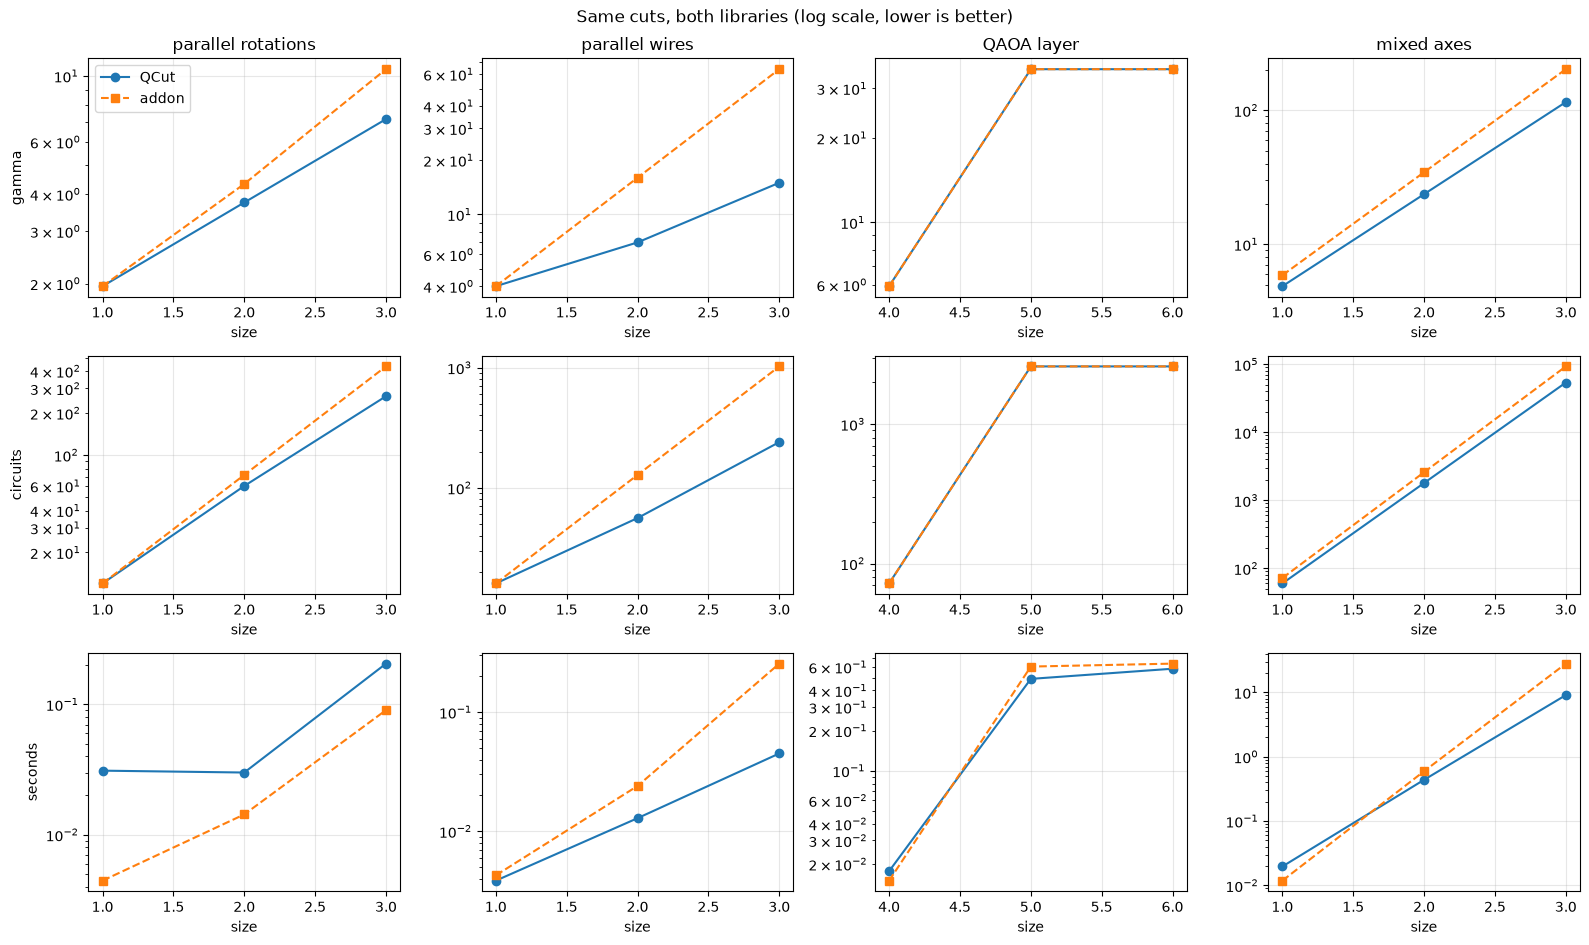

In [5]:
families = list(FAMILIES)
metrics = ("gamma", "circuits", "seconds")
fig, axes = plt.subplots(
    len(metrics), len(families), figsize=(4 * len(families), 3.2 * len(metrics))
)

for column, family in enumerate(families):
    block = same[same.family == family]
    for row, metric in enumerate(metrics):
        ax = axes[row, column]
        for library, marker in (("QCut", "o-"), ("addon", "s--")):
            part = block[block.library == library].sort_values("size")
            ax.plot(part["size"], part[metric], marker, label=library)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(family)
        if column == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("size")

axes[0, 0].legend()
fig.suptitle("Same cuts, both libraries (log scale, lower is better)")
fig.tight_layout()

## Which QCut option is responsible

The addon has no equivalent of consolidation, joint rotation cutting or of communicating wire cuts, so turning them off should reproduce its numbers.

In [6]:
off = CutOptions(
    joint_rotation_cuts=False,
    wire_cut_communication="never",
    consolidate="never",
    expansion="exact",
)

rows = []
for family, (build, sizes) in FAMILIES.items():
    for size in sizes:
        marked, _addon, labels, _wire_cuts = build(size)
        plain_gamma, *_ = run_qcut(
            marked, single_z(marked.num_qubits), off, budget_from(labels)
        )
        block = same[(same.family == family) & (same["size"] == size)]
        rows.append(
            {
                "family": family,
                "size": size,
                "addon": float(block[block.library == "addon"]["gamma"].iloc[0]),
                "qcut_features_off": plain_gamma,
                "qcut_default": float(block[block.library == "QCut"]["gamma"].iloc[0]),
            }
        )

attribution = pd.DataFrame(rows)
attribution["off == addon"] = np.isclose(
    attribution["qcut_features_off"], attribution["addon"], rtol=1e-6
)
attribution.round(4)

,family,size,addon,qcut_features_off,qcut_default,off == addon
0,parallel rotations,1,1.9589,1.9589,1.9589,True
1,parallel rotations,2,4.3298,4.3298,3.7495,True
2,parallel rotations,3,10.5418,10.5418,7.1566,True
3,parallel wires,1,4.0000,4.0000,4.0000,True
4,parallel wires,2,16.0000,16.0000,7.0000,True
5,parallel wires,3,64.0000,64.0000,15.0000,True
6,QAOA layer,4,5.9278,5.9278,5.9278,True
7,QAOA layer,5,35.1391,35.1391,35.1391,True
8,QAOA layer,6,35.1391,35.1391,35.1391,True
9,mixed axes,1,5.8736,5.8736,4.8644,True


## Automatic cut finding

Each library picks its own cuts under the same qubit budget. Gamma is what it settled on, time is how long it took to decide.

In [7]:
def random_graph_circuit(nodes, degree=3, seed=11):
    """Dense-ish and expensive to partition: gamma climbs fast with size."""
    graph = nx.random_regular_graph(degree, nodes, seed=seed)
    circuit = QuantumCircuit(nodes)
    for q in range(nodes):
        circuit.h(q)
    for a, b in graph.edges():
        circuit.rzz(0.8, a, b)
    for q in range(nodes):
        circuit.rx(0.6, q)
    return circuit


def su2_circuit(nodes, reps=2):
    """A structured ansatz: large but cheap to partition, so gamma stays put and the
    only thing growing is how much circuit the finder has to look at."""
    circuit = efficient_su2(nodes, entanglement="linear", reps=reps).decompose()
    return circuit.assign_parameters([0.3] * circuit.num_parameters)


def two_qubit_gates(circuit):
    return sum(1 for i in circuit.data if i.operation.num_qubits == 2)


def time_qcut(circuit, budget):
    """Time the finder only. gamma comes from plan_cost, which is closed form -- the
    old version built every experiment circuit here, work the addon never does."""
    t = perf_counter()
    found = ck.find_cuts(
        circuit.copy(), options=CutOptions(finder_max_qubits=budget, seed=42)
    )
    seconds = perf_counter() - t
    return float(plan_cost(found, found.options)), len(found.cut_locations), seconds


def time_addon(circuit, budget):
    t = perf_counter()
    _, metadata = find_cuts(
        circuit.copy(),
        OptimizationParameters(seed=42),
        DeviceConstraints(qubits_per_subcircuit=budget),
    )
    seconds = perf_counter() - t
    # sampling_overhead is gamma squared
    return (
        math.sqrt(metadata["sampling_overhead"]),
        len(metadata.get("cuts", [])),
        seconds,
    )


# a throwaway call so the first measurement is not paying for import-time work
time_qcut(su2_circuit(6), 3)

cases = (
    [
        ("random graph", n, random_graph_circuit(n), n // 2)
        for n in (6, 8, 10, 12, 20, 40)
    ]
    + [("SU2 width", n, su2_circuit(n), n // 2) for n in (8, 16, 24, 32, 48, 64)]
    + [("SU2 depth", 16, su2_circuit(16, reps=r), 8) for r in (2, 4, 8, 16, 24)]
)

rows = []
for kind, nodes, circuit, budget in cases:
    for library, measure in (("QCut", time_qcut), ("addon", time_addon)):
        gamma, cuts, seconds = measure(circuit, budget)
        rows.append(
            {
                "kind": kind,
                "nodes": nodes,
                "gates_2q": two_qubit_gates(circuit),
                "library": library,
                "gamma": gamma,
                "cuts": cuts,
                "seconds": seconds,
            }
        )

finder = pd.DataFrame(rows)
finder.round(4)

/home/nivalajo/work/QCut/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,kind,nodes,gates_2q,library,gamma,cuts,seconds
0,random graph,6,9,QCut,1.443250e+01,3,0.0296
1,random graph,6,9,addon,1.443250e+01,3,0.0107
2,random graph,8,12,QCut,3.513910e+01,4,0.0346
3,random graph,8,12,addon,3.513910e+01,4,0.0725
4,random graph,10,15,QCut,7.069960e+01,5,0.0451
5,random graph,10,15,addon,8.555360e+01,5,0.6370
6,random graph,12,18,QCut,2.903820e+01,4,0.0460
7,random graph,12,18,addon,3.513910e+01,4,0.4382
8,random graph,20,30,QCut,2.082983e+02,6,0.0745
9,random graph,20,30,addon,7.319414e+03,10,9.4743


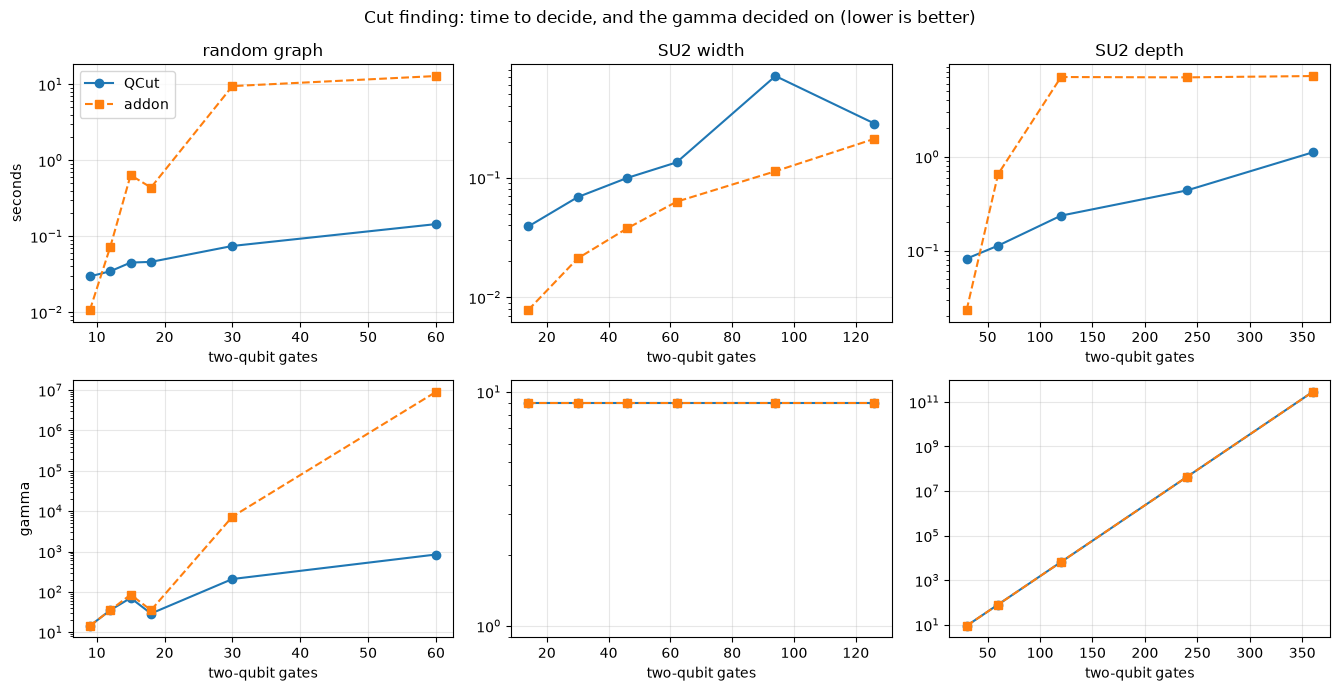

In [8]:
kinds = ["random graph", "SU2 width", "SU2 depth"]
fig, axes = plt.subplots(2, len(kinds), figsize=(4.5 * len(kinds), 7))

for column, kind in enumerate(kinds):
    block = finder[finder.kind == kind]
    for row, metric in enumerate(("seconds", "gamma")):
        ax = axes[row, column]
        for library, marker in (("QCut", "o-"), ("addon", "s--")):
            part = block[block.library == library].sort_values("gates_2q")
            ax.plot(part["gates_2q"], part[metric], marker, label=library)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("two-qubit gates")
        if row == 0:
            ax.set_title(kind)
        if column == 0:
            ax.set_ylabel(metric)

axes[0, 0].legend()
fig.suptitle("Cut finding: time to decide, and the gamma decided on (lower is better)")
fig.tight_layout()

## What each library has that the other does not

| | QCut | addon |
| --- | --- | --- |
| Joint cutting of parallel rotation gates | yes | no |
| Wire cuts with classical communication | yes | no |
| Merging consecutive gates on a pair before cutting | yes | no |
| Generic two-qubit gate cut from the gate's own matrix | yes | yes |
| Automatic cut finding | yes | yes |
| Cut finding under a qubit budget | yes | yes |
| Sampling instead of full enumeration | yes | yes |
| Runs on IQM hardware directly | yes | via transpilation |
| Qiskit primitives / Runtime integration | yes | yes |
| Probability reconstruction | yes | no |
| Cut finding with an explicit gamma ceiling | no | yes (`max_gamma`) |